In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# プロジェクトのsrcディレクトリをimportパスに追加
import os
import sys

output_path = os.path.abspath(os.path.join('..', 'output/sar02'))
# output_path = os.path.abspath(os.path.join('..', 'java-project', 'output'))
if output_path not in sys.path:
    sys.path.append(output_path)

# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [2]:
params_df = pd.read_csv(os.path.join(output_path, "parameters.csv"))
metadata_df = pd.read_csv(os.path.join(output_path, "metadata.csv"))
metadata_dict = dict(zip(metadata_df["項目"], metadata_df["値"]))

display(params_df)
for key, value in metadata_dict.items():
    print(f"{key}: {value}")

,networkType,N,k_ave,lambdaMin,lambdaMax,dlambda,gamma,rho0,alphaMin,alphaMax,dalpha,transmissionThreshold,trendThreshold,tmax,batchNum,itrPerBatch
0,ER,4000,10,0.0,1.0,0.01,1.0,0.003,0.0,1.0,0.01,1,4,100,12,20


シミュレーション開始時間: 2025-08-10 03:06:33
シミュレーション終了時間: 2025-08-10 06:54:42
実行時間（秒）: 13689
実行時間（分）: 228.15
実行時間（時間）: 3.80
OS名: Mac OS X
OSバージョン: 15.6
Javaバージョン: 24.0.2
Javaベンダー: Homebrew
利用可能プロセッサ数: nan
総メモリ: 7752 MB
最大メモリ: 12288 MB


In [3]:
network_type = params_df["networkType"].values[0]
N = params_df["N"].values[0]
k_ave = params_df["k_ave"].values[0]
lambda_min = params_df["lambdaMin"].values[0]
lambda_max = params_df["lambdaMax"].values[0]
dlambda = params_df["dlambda"].values[0]
gamma = params_df["gamma"].values[0]
rho0 = params_df["rho0"].values[0]
alpha_min = params_df["alphaMin"].values[0]
alpha_max = params_df["alphaMax"].values[0]
dalpha = params_df["dalpha"].values[0]
transmission_threshold = params_df["transmissionThreshold"].values[0]
trend_threshold = params_df["trendThreshold"].values[0]
tmax = params_df["tmax"].values[0]
batch_num = params_df["batchNum"].values[0]
itr_per_batch = params_df["itrPerBatch"].values[0]

In [4]:
total_itr = batch_num * itr_per_batch
lambda_values = np.arange(lambda_min, lambda_max + dlambda, dlambda)
alpha_values = np.arange(alpha_min, alpha_max + dalpha, dalpha)

shape = (len(lambda_values), len(alpha_values), total_itr, tmax+1)
len_per_state = len(lambda_values) * len(alpha_values) * itr_per_batch * (tmax + 1)
S, A, R = np.zeros(shape), np.zeros(shape), np.zeros(shape)

for batch_idx in range(batch_num):
    file_name = os.path.join(output_path, f"results_{batch_idx}.csv")
    print(f"Downloading {(batch_idx + 1):02d} th file ...")
    values = np.loadtxt(file_name, delimiter=",", skiprows=1)
    reshaped = values.reshape((3, len(lambda_values), len(alpha_values), itr_per_batch, tmax+1))

    S[:, :, batch_idx * itr_per_batch:(batch_idx + 1) * itr_per_batch, :] = reshaped[0]
    A[:, :, batch_idx * itr_per_batch:(batch_idx + 1) * itr_per_batch, :] = reshaped[1]
    R[:, :, batch_idx * itr_per_batch:(batch_idx + 1) * itr_per_batch, :] = reshaped[2]

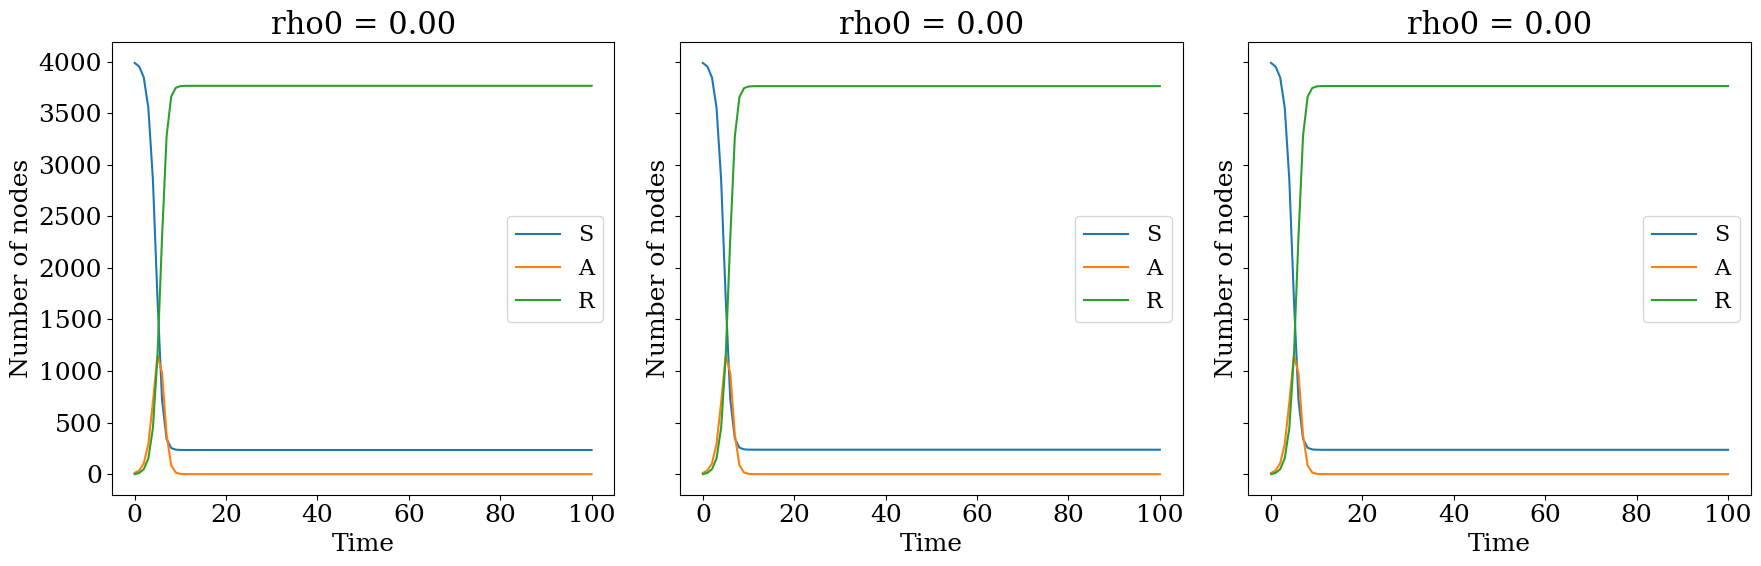

In [5]:
times = np.arange(tmax + 1)

lamdbda_idx = 30

alpha_idx_list = [0, 15, 30]

fig, axes = plt.subplots(1, len(alpha_idx_list), figsize=(6 * len(alpha_idx_list), 6), sharey=True)
for idx, alpha_idx in enumerate(alpha_idx_list):
    alpha = alpha_values[alpha_idx]
    plot_S = S[lamdbda_idx, alpha_idx, :, :].mean(axis=0)
    plot_A = A[lamdbda_idx, alpha_idx, :, :].mean(axis=0)
    plot_R = R[lamdbda_idx, alpha_idx, :, :].mean(axis=0)
    axes[idx].plot(times, plot_S, label="S")
    axes[idx].plot(times, plot_A, label="A")
    axes[idx].plot(times, plot_R, label="R")
    axes[idx].legend()
    axes[idx].set_title(f"rho0 = {rho0:.2f}")
    axes[idx].set_xlabel("Time")
    axes[idx].set_ylabel("Number of nodes")
    # axes[idx].set_xlim(0, 5)

plt.tight_layout()
plt.show()

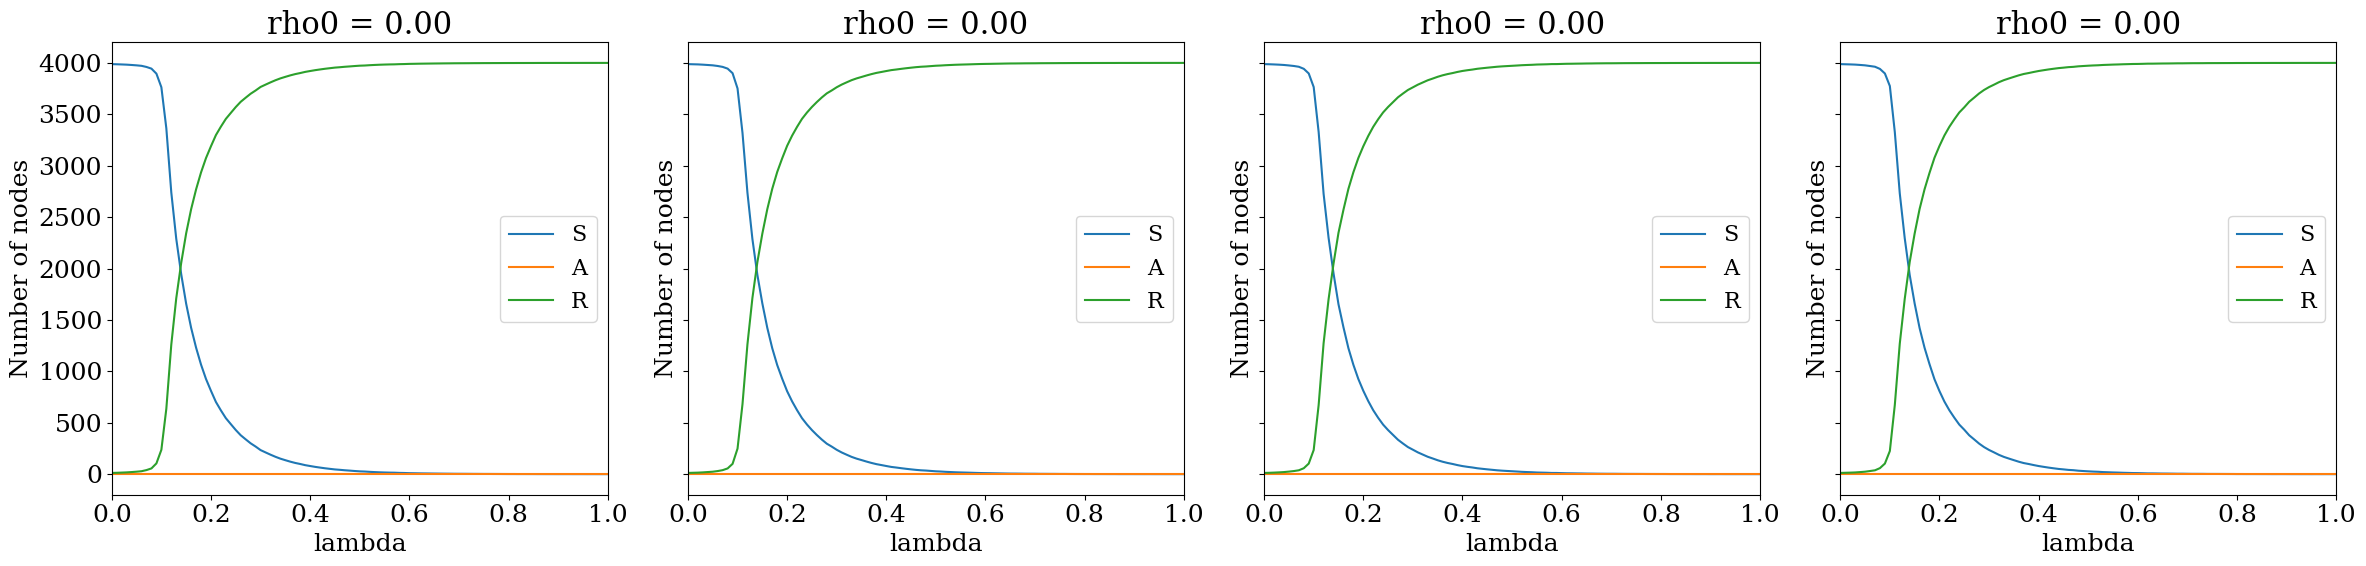

In [6]:
alpha_idx_list = [0, 2, 4, 6]

fig, axes = plt.subplots(1, len(alpha_idx_list), figsize=(6 * len(alpha_idx_list), 6), sharey=True)
for idx, alpha_idx in enumerate(alpha_idx_list):
    alpha = alpha_values[alpha_idx]
    plot_S = S[:, alpha_idx, :, -1].mean(axis=1)
    plot_A = A[:, alpha_idx, :, -1].mean(axis=1)
    plot_R = R[:, alpha_idx, :, -1].mean(axis=1)
    axes[idx].plot(lambda_values, plot_S, label="S")
    axes[idx].plot(lambda_values, plot_A, label="A")
    axes[idx].plot(lambda_values, plot_R, label="R")
    axes[idx].legend()
    axes[idx].set_title(f"rho0 = {rho0:.2f}")
    axes[idx].set_xlabel("lambda")
    axes[idx].set_ylabel("Number of nodes")
    axes[idx].set_xlim(0, 1)

plt.tight_layout()
plt.show()

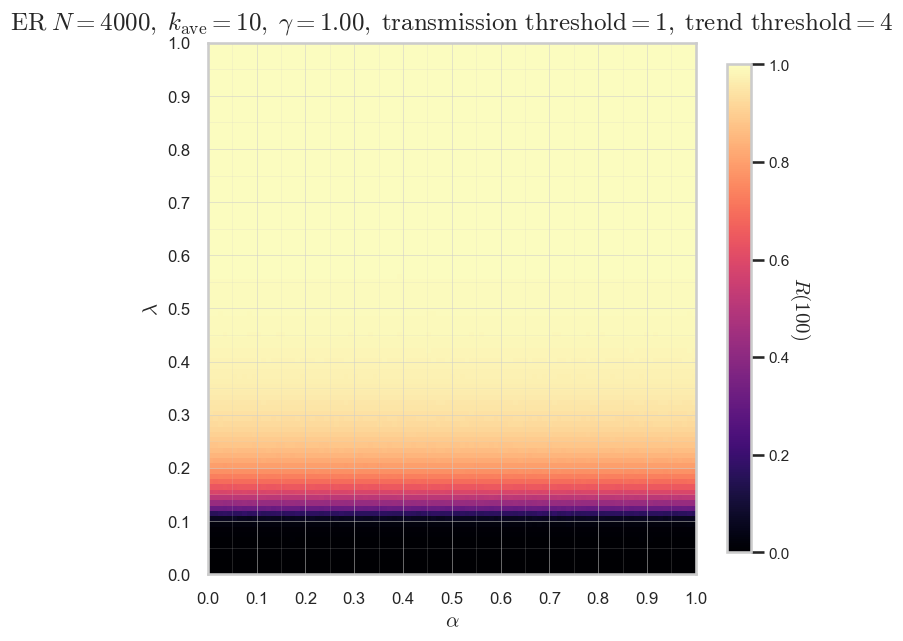

In [7]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import seaborn as sns

# 見やすいサイズ＆字間
sns.set_context("talk", font_scale=1.05)
sns.set_style("whitegrid")

# ---- Figure ----
fig = plt.figure(figsize=(6.8, 6.3), constrained_layout=True)  # 余白調整はconstrained_layoutに任せる
gs = GridSpec(1, 1, figure=fig)

# 値のスケール（0〜1）
vmin, vmax = 0.0, 1.0

# ---- Heatmap ----
ax = fig.add_subplot(gs[0, 0])

# Rの最終時刻を平均して正規化（shape: [lambda, alpha] を想定）
heat = (R[:, :, :, -1] / N).mean(axis=2)

im = ax.imshow(
    heat,
    extent=[0.0, 1.0, 0.0, 1.0],   # x=alpha, y=lambda
    origin="lower",
    aspect="auto",
    cmap="magma",
    vmin=vmin, vmax=vmax,
    interpolation="nearest"
)

# タイトル：数式のイタリックを抑え、字間を適度に
title = (
    rf"$\mathrm{{{network_type}}}\;N={N},\;"
    rf"k_{{\mathrm{{ave}}}}={k_ave},\;"
    rf"\gamma={gamma:.2f},\;"
    rf"\mathrm{{transmission\ threshold}}={transmission_threshold},\;"
    rf"\mathrm{{trend\ threshold}}={trend_threshold}$"
)
ax.set_title(title, fontsize=18, pad=10)  # padでタイトルと軸の間隔を広げる

# 軸ラベル
ax.set_xlabel(r"$\alpha$", fontsize=15)
ax.set_ylabel(r"$\lambda$", fontsize=15)

# 軸範囲きっちり（TeX表記の 0–1 に合わせる）
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)

# 目盛りを0.1〜0.2刻みで綺麗に
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.xaxis.set_minor_locator(MultipleLocator(0.05))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.tick_params(axis="both", which="major", labelsize=12)
ax.tick_params(axis="both", which="minor", length=3)

# グリッドは控えめに（minorも薄く）
ax.grid(linewidth=0.6, alpha=0.6)
ax.grid(which="minor", linewidth=0.4, alpha=0.3)

# ---- Colorbar：軸に紐づけてスマート配置 ----
# fractionで細さ、padで距離を調整。長すぎると感じたらshrinkを下げる
cbar = fig.colorbar(im, ax=ax, location="right", fraction=0.050, pad=0.04)
cbar.set_label(rf"$R({tmax})$", fontsize=15)
cbar.ax.tick_params(labelsize=11)
# ラベルを縦に・少し離す
cbar.set_label(rf"$R({tmax})$", rotation=270, labelpad=16, fontsize=15)

plt.show()
